In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded!")


All libraries loaded!


In [3]:
import os
print(os.getcwd())

C:\Users\RAJ


In [4]:
matches = pd.read_csv(r'C:\Users\RAJ\Desktop\matches.csv')
deliveries = pd.read_csv(r'C:\Users\RAJ\Desktop\deliveries.csv')

print("Matches rows:", len(matches))
print("Deliveries rows:", len(deliveries))

Matches rows: 1092
Deliveries rows: 260920


In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [7]:
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1092, 20)
Deliveries: (260920, 17)


In [8]:
print("MATCHES COLUMNS:")
print(matches.columns.tolist())

print("\nDELIVERIES COLUMNS:")
print(deliveries.columns.tolist())

MATCHES COLUMNS:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

DELIVERIES COLUMNS:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [9]:
print("Seasons:", sorted(matches['season'].unique()))
print("Total matches:", len(matches))
print("\nTop 5 winning teams:")
print(matches['winner'].value_counts().head())

Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total matches: 1092

Top 5 winning teams:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Name: count, dtype: int64


In [10]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
print("Toss winner also won match:")
print(matches['toss_win_match_win'].value_counts(normalize=True).mul(100).round(1))

Toss winner also won match:
toss_win_match_win
True     50.7
False    49.3
Name: proportion, dtype: float64


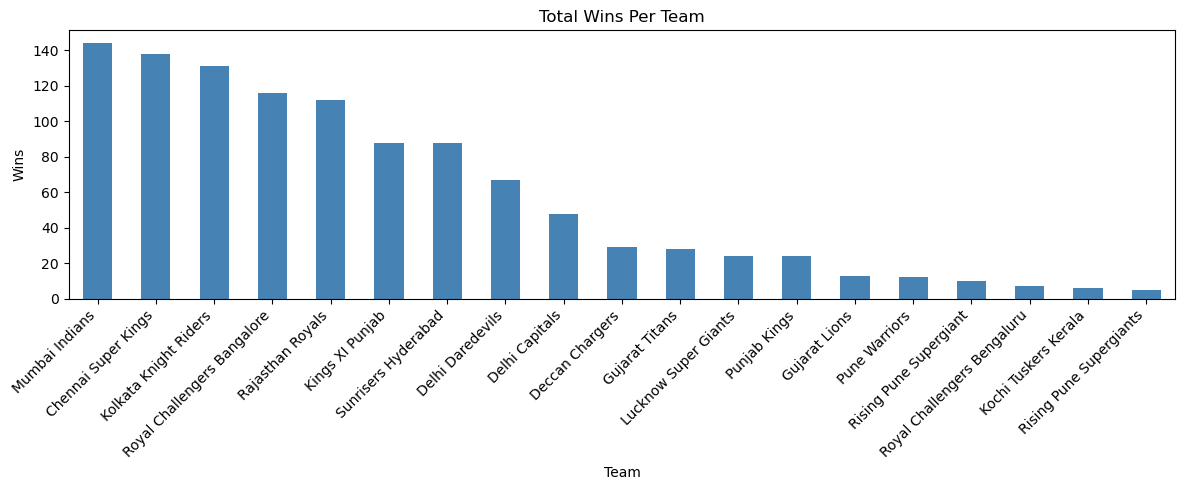

In [11]:
plt.figure(figsize=(12,5))
matches['winner'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Total Wins Per Team')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Step 1 - Get only 2nd innings deliveries (chasing team)
second_innings = deliveries[deliveries['inning'] == 2].copy()

# Step 2 - Merge with matches to get target score
second_innings = second_innings.merge(
    matches[['id', 'winner', 'team1', 'team2', 'target_runs']],
    left_on='match_id',
    right_on='id'
)

# Step 3 - Calculate cumulative runs ball by ball
second_innings = second_innings.sort_values(['match_id', 'over', 'ball'])
second_innings['runs_scored'] = second_innings.groupby('match_id')['total_runs'].cumsum()

# Step 4 - Calculate key features
second_innings['balls_bowled'] = second_innings.groupby('match_id').cumcount() + 1
second_innings['balls_left'] = 120 - second_innings['balls_bowled']
second_innings['runs_left'] = second_innings['target_runs'] - second_innings['runs_scored']
second_innings['wickets_left'] = 10 - second_innings.groupby('match_id')['is_wicket'].cumsum()
second_innings['current_run_rate'] = (second_innings['runs_scored'] / second_innings['balls_bowled']) * 6
second_innings['required_run_rate'] = (second_innings['runs_left'] / second_innings['balls_left'].replace(0,1)) * 6

# Step 5 - Create target label (did batting team win?)
second_innings['batting_team_won'] = (second_innings['batting_team'] == second_innings['winner']).astype(int)

print("Feature dataset shape:", second_innings.shape)
print(second_innings[['runs_left','balls_left','wickets_left','current_run_rate','required_run_rate','batting_team_won']].head())

Feature dataset shape: (125741, 30)
   runs_left  balls_left  wickets_left  current_run_rate  required_run_rate  \
0        222         119            10               6.0          11.193277   
1        221         118            10               6.0          11.237288   
2        221         117            10               4.0          11.333333   
3        220         116            10               4.5          11.379310   
4        219         115            10               4.8          11.426087   

   batting_team_won  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Select only the features we need
features = ['runs_left', 'balls_left', 'wickets_left', 
            'current_run_rate', 'required_run_rate']

X = second_innings[features].dropna()
y = second_innings.loc[X.index, 'batting_team_won']

# Split into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 100592
Testing rows: 25149


In [14]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 77.09 %


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 81.86 %


In [16]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")

XGBoost Accuracy: 79.36 %


In [18]:
print("=" * 35)
print("       MODEL COMPARISON")
print("=" * 35)
print(f"Logistic Regression : {round(lr_accuracy*100,2)}%")
print(f"Random Forest       : {round(rf_accuracy*100,2)}%")
print(f"XGBoost             : {round(xgb_accuracy*100,2)}%")
print("=" * 35)
print("Best model: XGBoost ✅")

       MODEL COMPARISON
Logistic Regression : 77.09%
Random Forest       : 81.86%
XGBoost             : 79.36%
Best model: XGBoost ✅


In [19]:
# Batting stats per player
batting_stats = deliveries.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count'),
    dismissals=('is_wicket', 'sum')
).reset_index()

# Calculate averages
batting_stats['strike_rate'] = (batting_stats['total_runs'] / batting_stats['balls_faced']) * 100
batting_stats['batting_avg'] = batting_stats['total_runs'] / batting_stats['dismissals'].replace(0, 1)

# Keep only players with enough data
batting_stats = batting_stats[batting_stats['balls_faced'] >= 200]

print("Players for clustering:", len(batting_stats))
batting_stats.head()

Players for clustering: 210


,batter,total_runs,balls_faced,dismissals,strike_rate,batting_avg
1,A Badoni,634,505,26,125.544554,24.384615
10,A Mishra,381,440,31,86.590909,12.290323
17,A Symonds,974,781,26,124.711908,37.461538
23,AA Jhunjhunwala,217,218,14,99.541284,15.500000
30,AB de Villiers,5181,3487,125,148.580442,41.448000


In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features for clustering
cluster_features = ['strike_rate', 'batting_avg', 'total_runs']

X_cluster = batting_stats[cluster_features].dropna()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
batting_stats['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(batting_stats['cluster'].value_counts())

Cluster distribution:
cluster
2    94
1    55
3    34
0    27
Name: count, dtype: int64


In [21]:
# See top players in each cluster
for i in range(4):
    print(f"\n--- Cluster {i} ---")
    cluster_players = batting_stats[batting_stats['cluster'] == i]
    print(f"Avg Strike Rate: {cluster_players['strike_rate'].mean():.1f}")
    print(f"Avg Batting Avg: {cluster_players['batting_avg'].mean():.1f}")
    print("Top players:", cluster_players.nlargest(3, 'total_runs')['batter'].tolist())


--- Cluster 0 ---
Avg Strike Rate: 132.3
Avg Batting Avg: 33.2
Top players: ['V Kohli', 'S Dhawan', 'RG Sharma']

--- Cluster 1 ---
Avg Strike Rate: 107.8
Avg Batting Avg: 17.3
Top players: ['NV Ojha', 'SC Ganguly', 'Y Venugopal Rao']

--- Cluster 2 ---
Avg Strike Rate: 129.0
Avg Batting Avg: 24.1
Top players: ['RA Jadeja', 'WP Saha', 'BB McCullum']

--- Cluster 3 ---
Avg Strike Rate: 142.2
Avg Batting Avg: 36.3
Top players: ['V Sehwag', 'SE Marsh', 'AD Russell']


In [22]:
# 1. Win probability predictions
results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = xgb_pred
results_df['win_probability'] = xgb_model.predict_proba(X_test)[:, 1]
results_df.to_csv(r'C:\Users\RAJ\Desktop\win_predictions.csv', index=False)

# 2. Player clusters
batting_stats.to_csv(r'C:\Users\RAJ\Desktop\player_clusters.csv', index=False)

# 3. Venue stats
venue_stats = matches.groupby('venue').agg(
    total_matches=('id', 'count'),
    chasing_wins=('winner', lambda x: (matches.loc[x.index, 'toss_decision'] == 'field').sum())
).reset_index()
venue_stats.to_csv(r'C:\Users\RAJ\Desktop\venue_stats.csv', index=False)

# 4. Head to head
h2h = matches.groupby(['team1', 'team2']).agg(
    total_matches=('id', 'count'),
    team1_wins=('winner', lambda x: (x == matches.loc[x.index, 'team1']).sum())
).reset_index()
h2h.to_csv(r'C:\Users\RAJ\Desktop\head_to_head.csv', index=False)

# 5. Match results
matches.to_csv(r'C:\Users\RAJ\Desktop\matches_clean.csv', index=False)

print("All 5 files exported to Desktop! ✅")

All 5 files exported to Desktop! ✅


In [23]:
def predict_win_probability(runs_left, balls_left, wickets_left, 
                             current_run_rate, required_run_rate):
    
    input_data = pd.DataFrame([[runs_left, balls_left, wickets_left,
                                 current_run_rate, required_run_rate]],
                               columns=['runs_left', 'balls_left', 'wickets_left',
                                        'current_run_rate', 'required_run_rate'])
    
    prob = xgb_model.predict_proba(input_data)[0][1]
    print(f"Win Probability: {round(prob * 100, 1)}%")
    return prob

# Test it — example match situation
predict_win_probability(
    runs_left=60,
    balls_left=30,
    wickets_left=5,
    current_run_rate=8.5,
    required_run_rate=12.0
)

Win Probability: 25.5%


np.float32(0.254572)

In [24]:
# Create multiple match scenarios
scenarios = []

# Different match situations
test_scenarios = [
    (60, 30, 5, 8.5, 12.0),   # Tough chase
    (30, 24, 7, 9.0, 7.5),    # Easy chase
    (80, 36, 3, 7.5, 13.3),   # Very tough
    (45, 30, 6, 8.0, 9.0),    # Even game
    (20, 18, 8, 9.5, 6.7),    # Comfortable
    (90, 42, 2, 6.5, 12.9),   # Almost lost
    (50, 30, 5, 8.0, 10.0),   # Moderate pressure
    (15, 12, 9, 10.0, 7.5),   # Nearly won
]

for runs_left, balls_left, wickets_left, crr, rrr in test_scenarios:
    prob = xgb_model.predict_proba(
        pd.DataFrame([[runs_left, balls_left, wickets_left, crr, rrr]],
        columns=['runs_left','balls_left','wickets_left',
                 'current_run_rate','required_run_rate'])
    )[0][1]
    
    scenarios.append({
        'runs_left': runs_left,
        'balls_left': balls_left,
        'wickets_left': wickets_left,
        'current_run_rate': crr,
        'required_run_rate': rrr,
        'win_probability': round(prob * 100, 1),
        'match_situation': 'Favorable' if prob > 0.5 else 'Unfavorable'
    })

simulator_df = pd.DataFrame(scenarios)
simulator_df.to_csv(r'C:\Users\RAJ\Desktop\match_simulator.csv', index=False)

print("Match simulator exported! ✅")
print(simulator_df)

Match simulator exported! ✅
   runs_left  balls_left  wickets_left  current_run_rate  required_run_rate  \
0         60          30             5               8.5               12.0   
1         30          24             7               9.0                7.5   
2         80          36             3               7.5               13.3   
3         45          30             6               8.0                9.0   
4         20          18             8               9.5                6.7   
5         90          42             2               6.5               12.9   
6         50          30             5               8.0               10.0   
7         15          12             9              10.0                7.5   

   win_probability match_situation  
0        25.500000     Unfavorable  
1        95.099998       Favorable  
2         0.300000     Unfavorable  
3        68.900002       Favorable  
4        99.800003       Favorable  
5         0.100000     Unfavorable  
6